# Stage 8, Part 4: Fine-Tuning a Pretrained Transformer

**Goal:** fine-tune DistilBERT (a real, pretrained Transformer) on the SAME spam dataset used in Stage 6 and Part 1, completing a genuine three-way comparison:

| Approach | Where | Technique |
|---|---|---|
| TF-IDF + Logistic Regression | Stage 6 | Fixed frequency-based features |
| Learned embeddings + NN (from scratch) | Part 1 | Randomly initialized embeddings, trained only on your ~5,500 messages |
| Fine-tuned DistilBERT | This notebook | Embeddings + Transformer blocks PRETRAINED on billions of words, adapted to your task |

**Why this comparison matters:** it's the direct, hands-on answer to "why does everyone talk about pretraining." DistilBERT has already learned rich language structure from a massive corpus before it ever sees a single spam message — fine-tuning just nudges that existing knowledge toward your specific task, rather than learning language from nothing on a small dataset.

## 1. Load the data (same as Stage 6 / Part 1)

In [1]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

# TODO: load (tab-separated, no header, columns ['label', 'message']), map label to 0/1
# TODO: split train/val (stratified) -- keep RAW text this time, no manual cleaning/tokenizing needed,
# the pretrained tokenizer handles that

df = pd.read_csv(
    url,
    sep='\t',
    header=None,
    names=['label','message']

)

# X = input text
X = df['message']

# y = target
# ham = 0, spam = 1
y = df['label'].map({'ham': 0, 'spam': 1})

# 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split the 30% temporary set into:
# 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)





## 2. Load the pretrained tokenizer and model

**Syntax note:** `AutoTokenizer.from_pretrained('distilbert-base-uncased')` downloads DistilBERT's own tokenizer — NOT the word-level one you built in Part 1. This is a real subword/WordPiece tokenizer (the BPE-family approach mentioned back in Part 1's crash course), with a vocabulary of ~30,000 tokens learned from a massive corpus. `AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)` loads DistilBERT's pretrained weights, with a fresh (randomly initialized) classification head on top — that head is the only part starting from scratch.

Guiding question: given everything you now know about tokenization from Part 1, what would you expect DistilBERT's tokenizer to do with a word like "tokenization" itself, or a rare/made-up word? Try it and see.

In [3]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

print(tokenizer.tokenize("tokenization"))
print(tokenizer.tokenize("supercalifragilisticexpialidocious"))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


['token', '##ization']
['super', '##cal', '##if', '##rag', '##ilis', '##tic', '##ex', '##pia', '##lid', '##oc', '##ious']


## 3. Tokenize the dataset

**Syntax note:** `tokenizer(list_of_texts, padding=True, truncation=True, max_length=128, return_tensors='pt')` handles tokenization, padding, AND truncation all in one call — the manual `<PAD>`/`<UNK>`/padding logic you wrote by hand in Part 1 is all handled internally here. This returns a dictionary with `input_ids` and `attention_mask` (a mask telling the model which positions are real tokens vs. padding — conceptually related to your causal mask from Part 2, though this one marks padding rather than future positions).

In [4]:
# TODO: tokenize X_train and X_val (as lists of strings) with the settings above
# TODO: also convert y_train/y_val to torch tensors

# Tokenize text
token_X_train = tokenizer(
    X_train.tolist(),
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

token_X_val = tokenizer(
    X_val.tolist(),
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

# Convert labels to tensors
y_train_tensor = torch.tensor(
    y_train.tolist(),
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val.tolist(),
    dtype=torch.long
)



## 4. Fine-tuning loop

**Syntax note on learning rate:** use something small, like `2e-5` — much smaller than the `3e-4`/`1e-3` you used training from scratch in Parts 1 and 3. This is deliberate: DistilBERT's weights already encode a huge amount of useful structure from pretraining. A large learning rate would aggressively overwrite that pretrained knowledge (sometimes called "catastrophic forgetting") rather than gently adapting it. Fine-tuning typically only needs a few epochs, not thousands of steps.

**Syntax note on the model call:** `model(input_ids=..., attention_mask=..., labels=...)` — when you pass `labels` directly, HuggingFace models compute the loss internally and return it as part of the output object (`output.loss`), so you don't need a separate `criterion` call like in Parts 1/3.

In [5]:
import torch.optim as optim

optimizer = optim.AdamW(model.parameters(), lr=2e-5)

n_epochs = 3
loss_history = []
batch_size = 16


# TODO: training loop -- for a few epochs, in batches (you can slice manually or use DataLoader):
#   optimizer.zero_grad()
#   output = model(input_ids=batch_ids, attention_mask=batch_mask, labels=batch_labels)
#   loss = output.loss
#   loss.backward()
#   optimizer.step()
#   record loss.item()
# NOTE: this dataset is small (~5,500 messages) and DistilBERT is much bigger than your Part 1 model --
# training will be noticeably slower per step. Consider using a small batch size (8-16) and printing
# progress periodically so you can see it's actually running.




for epoch in range(n_epochs):

    for i in range(0, len(y_train_tensor), batch_size):

        # Get batch
        batch_ids = token_X_train["input_ids"][i:i+batch_size]
        batch_mask = token_X_train["attention_mask"][i:i+batch_size]
        batch_labels = y_train_tensor[i:i+batch_size]

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        output = model(
            input_ids=batch_ids,
            attention_mask=batch_mask,
            labels=batch_labels
        )

        # Get loss
        loss = output.loss

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Record loss
        loss_history.append(loss.item())

    print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss.item():.4f}")



Epoch 1/3, Loss: 0.0051
Epoch 2/3, Loss: 0.0014
Epoch 3/3, Loss: 0.0004


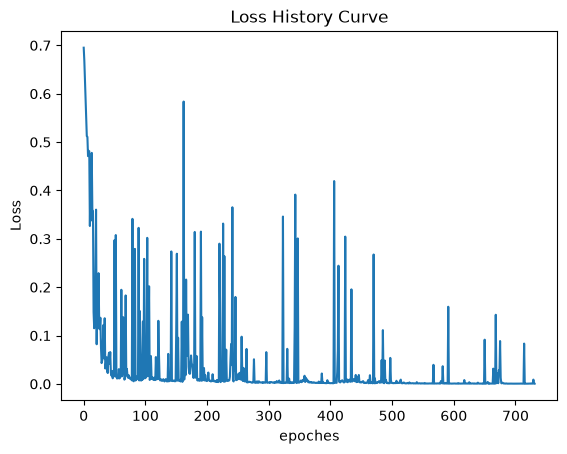

In [ ]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("batches")
plt.ylabel("Loss")
plt.title("Loss History Curve")
plt.show()




## 5. Evaluate and build the three-way comparison

Reuse your Stage 5 toolkit. Then pull your actual F1 numbers from Stage 6 (TF-IDF + LogReg) and Part 1 (from-scratch embeddings) and build one final table.

In [16]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for i in range(0, len(y_val_tensor), batch_size):

        batch_ids = token_X_val["input_ids"][i:i+batch_size]
        batch_mask = token_X_val["attention_mask"][i:i+batch_size]
        batch_labels = y_val_tensor[i:i+batch_size]

        outputs = model(
            input_ids=batch_ids,
            attention_mask=batch_mask
        )

        # [batch_size, 2] -> [batch_size]
        predictions = torch.argmax(outputs.logits, dim=1)

        # Convert tensors directly to individual integers
        all_predictions.extend(predictions.cpu().numpy().tolist())
        all_labels.extend(batch_labels.cpu().numpy().tolist())

# Convert to 1D NumPy arrays
all_predictions = np.array(all_predictions).reshape(-1)
all_labels = np.array(all_labels).reshape(-1)

print("Predictions shape:", all_predictions.shape)
print("Labels shape:", all_labels.shape)
print("Predictions:", all_predictions[:10])
print("Labels:", all_labels[:10])
print("Unique predictions:", np.unique(all_predictions))
print("Unique labels:", np.unique(all_labels))

print("\nAccuracy:", accuracy_score(all_labels, all_predictions))
print("Precision:", precision_score(all_labels, all_predictions))
print("Recall:", recall_score(all_labels, all_predictions))
print("F1:", f1_score(all_labels, all_predictions))
print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_predictions))
print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_predictions,
    target_names=["ham", "spam"]
))

Predictions shape: (836,)
Labels shape: (836,)
Predictions: [0 0 0 0 0 0 0 1 0 0]
Labels: [0 0 0 0 0 0 0 1 0 0]
Unique predictions: [0 1]
Unique labels: [0 1]

Accuracy: 0.992822966507177
Precision: 0.9732142857142857
Recall: 0.9732142857142857
F1: 0.9732142857142857

Confusion Matrix:
[[721   3]
 [  3 109]]

Classification Report:
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00       724
        spam       0.97      0.97      0.97       112

    accuracy                           0.99       836
   macro avg       0.98      0.98      0.98       836
weighted avg       0.99      0.99      0.99       836



In [17]:
# TODO: build a comparison table -- three rows (TF-IDF+LogReg, from-scratch embeddings, fine-tuned DistilBERT),
# pulling your ACTUAL recorded F1 scores from Stage 6 and Part 1, plus this notebook's real result



comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "From-scratch embeddings",
        "Fine-tuned DistilBERT"
    ],
    "Features": [
        "TF-IDF",
        "Learned embeddings",
        "DistilBERT"
    ],
    "Precision": [
        0.987342,
        0.9801980198019802,
        0.9732142857142857
    ],
    "Recall": [
        0.696429,
        0.8839285714285714,
        0.9732142857142857
    ],
    "F1": [
        0.816754,
        0.9295774647887324,
        0.9732142857142857
    ]
})

comparison




,Model,Features,Precision,Recall,F1
0,Logistic Regression,TF-IDF,0.987342,0.696429,0.816754
1,From-scratch embeddings,Learned embeddings,0.980198,0.883929,0.929577
2,Fine-tuned DistilBERT,DistilBERT,0.973214,0.973214,0.973214


Guiding question: did fine-tuning actually outperform your from-scratch embedding model? Given how small this dataset is (~5,500 messages) and how much larger DistilBERT is, would you have expected fine-tuning to help a LOT, a little, or possibly not at all on a task this simple? What does your actual result tell you about when pretraining's advantage matters most?

The fine tuning model actually out performed my from scratch embedding model by a signifacant amount 5%, this is because recall was a bit higher which pulled the difference. Pretraining's advantage is that it has learned general language representation from a huge amount of text before it solved my spam/ham issue.

## Wrap-up

Write a short summary:
- Fill in the final three-way comparison table with your real numbers, and state which approach won
- What's fundamentally different about fine-tuning's STARTING POINT compared to Part 1's from-scratch training — not the code, the actual weights the model begins with?
- If you had to deploy ONE of these three approaches in a real product tomorrow, which would you pick, and what would you weigh besides raw F1 (inference speed, model size, training cost, interpretability)?

The fine tuning model approach won on F1 score by a signficant difference ~5%. Fine tuning's starting point is that it was already pretrained on a lot of data beforehand so it is usually a larger/complex model, already started with learned representation and converges faster. In the real world, for cost and time efficiency, fine tuning a model is definintly the most optimal thing to do ( considering if it is a large dataset we are dealing with).